# Sistem za personalizovane preporuke knjiga — prezentacioni Jupyter notebook

## Autori:
    Darinka Lončar SV31/2022
    Dušica Pešić SV46/2022
## Cilj: demonstracija hibridnog Neural Collaborative Filtering (NCF) sistema za preporuke knjiga.

## 1) Sadržaj
1. Postavljanje okruženja i uvozi
2. Učitavanje i pregled podataka (Book‑Crossing)
3. Pretprocesiranje (filter, mapiranje, normalizacija)
4. Model (HybridNCF) — definicija i helperi
5. Trening (demo + checkpointing)
6. Evaluacija: RMSE, Precision@K
7. Vizualizacije i primeri preporuka
8. Zaključak i naredni koraci

In [32]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2) Učitavanje i pregled podataka

Očekuje se folder `data/` sa sledećim CSV fajlovima (Book‑Crossing format):

- **books.csv**: informacije o knjigama
  - Kolone: `"ISBN"`, `"Book-Author"`, `"Year-Of-Publication"`, `"Publisher"`
- **ratings.csv**: ocene korisnika
  - Kolone: `"User-ID"`, `"ISBN"`, `"Book-Rating"`
- **users.csv**: informacije o korisnicima
  - Kolone: `"User-ID"`, `"Age"`

In [33]:
DATA_DIR = 'data'
books_fp = Path(DATA_DIR) / 'books.csv'
ratings_fp = Path(DATA_DIR) / 'ratings.csv'
users_fp = Path(DATA_DIR) / 'users.csv'

print('Paths:')
print(books_fp)
print(ratings_fp)
print(users_fp)

Paths:
data/books.csv
data/ratings.csv
data/users.csv


In [34]:
def safe_read_csv(fp, **kwargs):
    return pd.read_csv(fp, sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False, **kwargs)

if books_fp.exists() and ratings_fp.exists() and users_fp.exists():
    books = safe_read_csv(books_fp)
    ratings = safe_read_csv(ratings_fp)
    users = safe_read_csv(users_fp)
    print('\nBooks shape:', books.shape)
    print('Ratings shape:', ratings.shape)
    print('Users shape:', users.shape)
else:
    books = pd.DataFrame()
    ratings = pd.DataFrame()
    users = pd.DataFrame()


Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


## 3) Pretprocesiranje (filter, mapiranje, normalizacija)

U ovoj fazi:
1. Standardizujemo nazive kolona.
2. Uklanjamo ocene koje su 0.
3. Filtriramo korisnike i knjige prema minimalnom broju ocena.
4. Mapiramo `user_id` i `book_id` u sekvencijalne indekse (`user_idx`, `book_idx`) radi lakše upotrebe u modelu.
5. Normalizujemo godinu objavljivanja knjige.
6. Pripremamo podskupove podataka (`users_sub`, `books_sub`, `ratings_sub`) koji sadrže samo relevantne podatke.


In [35]:
def preprocess(users, books, ratings, min_user_ratings=5, min_book_ratings=5):
    # rename columns to a standard set
    books = books.copy()
    ratings = ratings.copy()
    users = users.copy()

    books.columns = [c.strip() for c in books.columns]
    ratings.columns = [c.strip() for c in ratings.columns]
    users.columns = [c.strip() for c in users.columns]

    books.rename(columns={
        'ISBN': 'book_id',
        'Book-Author': 'author',
        'Year-Of-Publication': 'year',
        'Publisher': 'publisher'
    }, inplace=True)

    ratings.rename(columns={
        'User-ID': 'user_id',
        'ISBN': 'book_id',
        'Book-Rating': 'rating'
    }, inplace=True)

    users.rename(columns={
        'User-ID': 'user_id',
        'Age': 'age'
    }, inplace=True)

    # drop zero ratings
    if 'rating' in ratings.columns:
        ratings = ratings[ratings['rating'] != 0].copy()
    else:
        raise ValueError("ratings DataFrame missing 'rating' column")

    # filter users/books by count
    # remove all users who have less than min_user_ratings rated books
    # remove all books which have less than min_book_ratings ratings
    user_counts = ratings.groupby('user_id').size()
    book_counts = ratings.groupby('book_id').size()
    valid_users = set(user_counts[user_counts >= min_user_ratings].index)
    valid_books = set(book_counts[book_counts >= min_book_ratings].index)

    # if all books and users are removed, we undo the previous step
    if len(valid_users) == 0 or len(valid_books) == 0:
        valid_users = set(ratings['user_id'].unique())
        valid_books = set(ratings['book_id'].unique())

    ratings = ratings[ratings['user_id'].isin(valid_users) & ratings['book_id'].isin(valid_books)].copy()

    # remap to contiguous indices
    # due to book and user removal indices are bound to be messed up eg. unique_users = [10, 23, 42]
    unique_users = ratings['user_id'].unique()
    unique_books = ratings['book_id'].unique()
    user_map = {old: new for new, old in enumerate(unique_users)}
    book_map = {old: new for new, old in enumerate(unique_books)}

    # add new column which has good indices, user_map = {10:0, 23:1, 42:2}
    ratings['user_idx'] = ratings['user_id'].map(user_map)
    ratings['book_idx'] = ratings['book_id'].map(book_map)

    # after adding new indices to ratings dataframe, we make new dataframes for books and users,
    # that only contain valid info
    books_sub = books[books['book_id'].isin(book_map.keys())].copy()
    books_sub['book_idx'] = books_sub['book_id'].map(book_map)

    users_sub = users[users['user_id'].isin(user_map.keys())].copy()
    users_sub['user_idx'] = users_sub['user_id'].map(user_map)

    # age handling
    users_sub['age'] = pd.to_numeric(users_sub.get('age', -1), errors='coerce').fillna(-1).astype(float)
    books_sub['year'] = pd.to_numeric(books_sub.get('year', 0), errors='coerce').fillna(0)

    # year normalization
    mean = books_sub['year'].mean() if len(books_sub) > 0 else 0.0
    std = books_sub['year'].std() if len(books_sub) > 0 else 1.0
    books_sub['year_norm'] = (books_sub['year'] - mean) / (std + 1e-8)

    # fill missing author/publisher
    books_sub['author'] = books_sub.get('author', 'Unknown')
    books_sub['publisher'] = books_sub.get('publisher', 'Unknown')

    return users_sub.reset_index(drop=True), books_sub.reset_index(drop=True), ratings.reset_index(drop=True), user_map, book_map

In [36]:
if not ratings.empty:
    users_sub, books_sub, ratings_sub, user_map, book_map = preprocess(users, books, ratings, min_user_ratings=1, min_book_ratings=1)
    print('After preprocess: users', users_sub.shape, 'books', books_sub.shape, 'ratings', ratings_sub.shape)
else:
    print('No data loaded; preprocess was skipped')

After preprocess: users (77805, 4) books (149836, 10) ratings (433671, 5)


## 4) Model: HybridNCF i Dataset helper

U ovoj sekciji definišemo model **HybridNCF** koji kombinuje:
- **Embeddings** za korisnike, knjige, autore i izdavače
- **Numeričke karakteristike** (starost korisnika i normalizovanu godinu knjige)
- **MLP slojeve** za predikciju ocene

Takođe definišemo pomoćne klase za dataset i batch obradu.

In [37]:
class HybridNCF(nn.Module):
    def __init__(self,
                 n_users,
                 n_books,
                 n_authors,
                 n_publishers,
                 user_emb_dim=32,
                 item_emb_dim=32,
                 author_emb_dim=16,
                 pub_emb_dim=16,
                 mlp_layers=(128,64,32),
                 numeric_dim=2,
                 dropout=0.2):
        super().__init__()
        self.user_emb = nn.Embedding(max(1, n_users), user_emb_dim)
        self.item_emb = nn.Embedding(max(1, n_books), item_emb_dim)
        self.author_emb = nn.Embedding(max(1, n_authors), author_emb_dim)
        self.pub_emb = nn.Embedding(max(1, n_publishers), pub_emb_dim)

        concat_dim = user_emb_dim + item_emb_dim + author_emb_dim + pub_emb_dim + numeric_dim
        layers = []
        in_dim = concat_dim
        for out_dim in mlp_layers:
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

        # init
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.author_emb.weight, std=0.01)
        nn.init.normal_(self.pub_emb.weight, std=0.01)

    def forward(self, user_idx, item_idx, author_idx, pub_idx, user_age, book_year_norm):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        a = self.author_emb(author_idx)
        p = self.pub_emb(pub_idx)
        numerics = torch.stack([user_age, book_year_norm], dim=1)
        x = torch.cat([u, i, a, p, numerics], dim=1)
        out = self.mlp(x).squeeze(1)
        return out

# Dataset and collate
class RecDataset(Dataset):
    def __init__(self, ratings_df, users_df, books_df, author_map, pub_map):
        self.ratings = ratings_df.reset_index(drop=True)
        self.users = users_df.set_index('user_idx', drop=False)
        self.books = books_df.set_index('book_idx', drop=False)
        self.author_map = author_map
        self.pub_map = pub_map

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        row = self.ratings.iloc[idx]
        u_idx = int(row['user_idx'])
        b_idx = int(row['book_idx'])
        rating = float(row['rating'])

        if b_idx in self.books.index:
            book_row = self.books.loc[b_idx]
        else:
            book_row = pd.Series({'author': 'Unknown', 'publisher': 'Unknown', 'year_norm': 0.0})

        author = book_row.get('author', 'Unknown')
        pub = book_row.get('publisher', 'Unknown')
        author_idx = self.author_map.get(author, 0)
        pub_idx = self.pub_map.get(pub, 0)

        if u_idx in self.users.index:
            user_row = self.users.loc[u_idx]
        else:
            user_row = pd.Series({'age': -1})

        age = float(user_row.get('age', -1))
        year_norm = float(book_row.get('year_norm', 0.0))

        return {
            'user_idx': u_idx,
            'book_idx': b_idx,
            'author_idx': author_idx,
            'pub_idx': pub_idx,
            'age': age,
            'year_norm': year_norm,
            'rating': rating
        }

# collate_fn converts list-of-samples → batch-of-tensors.
def collate_fn(batch):
    return {
        'user_idx': torch.tensor([b['user_idx'] for b in batch], dtype=torch.long),
        'book_idx': torch.tensor([b['book_idx'] for b in batch], dtype=torch.long),
        'author_idx': torch.tensor([b['author_idx'] for b in batch], dtype=torch.long),
        'pub_idx': torch.tensor([b['pub_idx'] for b in batch], dtype=torch.long),
        'age': torch.tensor([b['age'] for b in batch], dtype=torch.float),
        'year_norm': torch.tensor([b['year_norm'] for b in batch], dtype=torch.float),
        'rating': torch.tensor([b['rating'] for b in batch], dtype=torch.float),
    }

# helper to build author/pub maps
def build_maps(books_df):
    authors = list(books_df['author'].unique())
    pubs = list(books_df['publisher'].unique())
    author_map = {a: i for i, a in enumerate(authors)}
    pub_map = {p: i for i, p in enumerate(pubs)}
    return author_map, pub_map

## 5) Trening (demo)

U ovoj sekciji treniramo naš **HybridNCF** model koristeći prethodno pripremljene podatke.
Cilj je naučiti model da predviđa ocene knjiga za korisnike.

In [38]:
if 'ratings_sub' in globals() and len(ratings_sub) > 0:
    author_map, pub_map = build_maps(books_sub)
    train_df, test_df = train_test_split(ratings_sub, test_size=0.2, random_state=42)
    train_ds = RecDataset(train_df, users_sub, books_sub, author_map, pub_map)
    test_ds = RecDataset(test_df, users_sub, books_sub, author_map, pub_map)
    # Wraps datasets in batches.
    # collate_fn converts list-of-samples → batch-of-tensors.
    # shuffle=True for training ensures randomized batches.
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate_fn)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = HybridNCF(
        n_users=len(user_map),
        n_books=len(book_map),
        n_authors=len(author_map),
        n_publishers=len(pub_map)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    EPOCHS = 2
    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        n_samples = 0
        for batch in tqdm(train_loader, desc=f'Train ep {epoch}'):
            optimizer.zero_grad()
            preds = model(batch['user_idx'].to(device), batch['book_idx'].to(device), batch['author_idx'].to(device), batch['pub_idx'].to(device), batch['age'].to(device), batch['year_norm'].to(device))
            loss = loss_fn(preds, batch['rating'].to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch['rating'].shape[0]
            n_samples += batch['rating'].shape[0]
        train_rmse = (total_loss / max(1, n_samples)) ** 0.5
        print(f"Epoch {epoch} Train RMSE: {train_rmse:.4f}")

        # evaluation
        model.eval()
        with torch.no_grad():
            sq = 0.0
            n = 0
            for batch in test_loader:
                preds = model(batch['user_idx'].to(device), batch['book_idx'].to(device), batch['author_idx'].to(device), batch['pub_idx'].to(device), batch['age'].to(device), batch['year_norm'].to(device))
                diff = (preds.cpu().numpy() - batch['rating'].numpy())
                sq += (diff ** 2).sum()
                n += len(diff)
            test_rmse = (sq / max(1, n)) ** 0.5
        print(f"Epoch {epoch} Test RMSE: {test_rmse:.4f}")

        os.makedirs('checkpoints', exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch
        }, f'checkpoints/checkpoint_epoch{epoch}.pth')

    os.makedirs('models', exist_ok=True)
    torch.save(model.state_dict(), 'models/model_final.pth')
    print('Training has finished. The model is saved here: models/model_final.pth')
else:
    print('No data → training skipped.')

Train ep 1: 100%|██████████| 1356/1356 [00:30<00:00, 44.62it/s]


Epoch 1 Train RMSE: 2.3889
Epoch 1 Test RMSE: 1.6514


Train ep 2: 100%|██████████| 1356/1356 [00:30<00:00, 44.06it/s]


Epoch 2 Train RMSE: 1.7630
Epoch 2 Test RMSE: 1.6691
Training has finished. The model is saved here: models/model_final.pth


## 6) Evaluacija: Precision@K i Recall@K

U ovoj sekciji merimo koliko su preporuke našeg modela relevantne koristeći **Precision@K** i **Recall@K**.

### Precision (preciznost)
Mera koliko su preporuke modela **tačne / relevantne**.
Izračunava se kao broj relevantnih stavki u top-K preporuka podeljen sa K.
> Formula: Precision@K = (broj relevantnih stavki u top K) / K

### Recall (odziv)
Mera koliko od svih relevantnih stavki za korisnika model uspe **da preporuči**.
Izračunava se kao broj relevantnih stavki u top-K preporuka podeljen sa ukupnim brojem relevantnih stavki.
> Formula: Recall@K = (broj relevantnih stavki u top K) / (ukupan broj relevantnih stavki)


In [69]:
def precision_recall_at_k(preds_dict, k=10):
    precisions = []
    recalls = []
    for u, items in preds_dict.items():
        items_sorted = sorted(items, key=lambda x: x[1], reverse=True)
        topk = items_sorted[:k]
        relevant_total = sum(1 for it in items if it[2])
        if relevant_total == 0:
            continue
        rel_in_topk = sum(1 for it in topk if it[2])
        precisions.append(rel_in_topk / k)
        recalls.append(rel_in_topk / relevant_total)
    if len(precisions) == 0:
        return 0.0, 0.0
    return float(np.mean(precisions)), float(np.mean(recalls))

if 'model' in globals() and 'test_loader' in globals():
    model.eval()
    user_preds = {}
    with torch.no_grad():
        for batch in test_loader:
            scores = model(batch['user_idx'].to(device), batch['book_idx'].to(device), batch['author_idx'].to(device), batch['pub_idx'].to(device), batch['age'].to(device), batch['year_norm'].to(device)).cpu().numpy()
            for u, b, s, r in zip(batch['user_idx'].numpy(), batch['book_idx'].numpy(), scores, batch['rating'].numpy()):
                user_preds.setdefault(int(u), []).append((int(b), float(s), float(r) >= 7))
    prec, rec = precision_recall_at_k(user_preds, k=10)
    print(f"Precision@10: {prec:.4f}, Recall@10: {rec:.4f}")

Precision@10: 0.2032, Recall@10: 0.9779


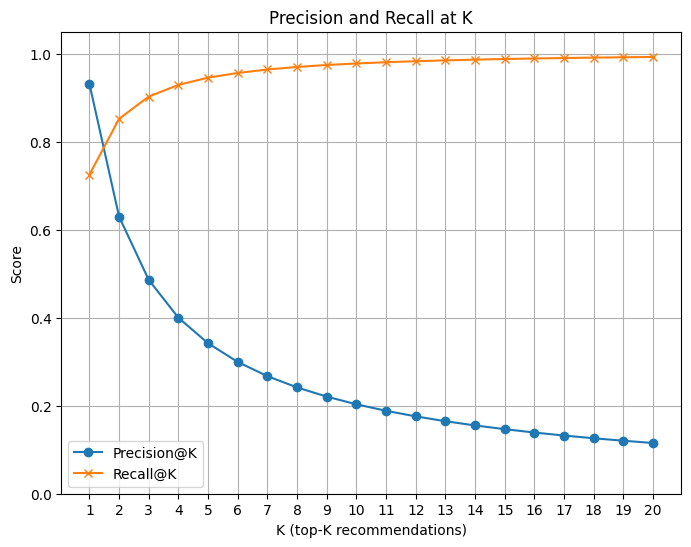

In [61]:

def plot_precision_recall_curve(user_preds, max_k=20):
    precisions = []
    recalls = []

    # Compute Precision and Recall for different K
    for k in range(1, max_k+1):
        prec, rec = precision_recall_at_k(user_preds, k=k)
        precisions.append(prec)
        recalls.append(rec)

    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(range(1, max_k+1), precisions, marker='o', label='Precision@K')
    plt.plot(range(1, max_k+1), recalls, marker='x', label='Recall@K')
    plt.title('Precision and Recall at K')
    plt.xlabel('K (top-K recommendations)')
    plt.ylabel('Score')
    plt.xticks(range(1, max_k+1))
    plt.ylim(0,1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
if 'user_preds' in globals():
    plot_precision_recall_curve(user_preds, max_k=20)


## 7) Vizualizacije i primeri preporuka

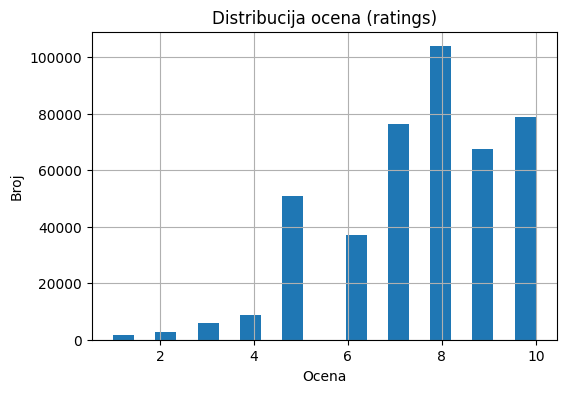

In [40]:
if 'ratings_sub' in globals() and len(ratings_sub) > 0:
    plt.figure(figsize=(6,4))
    ratings_sub['rating'].hist(bins=20)
    plt.title('Distribucija ocena (ratings)')
    plt.xlabel('Ocena')
    plt.ylabel('Broj')
    plt.show()

In [68]:
def show_top_recommendations(model, user_idx, books_sub, ratings_sub, users_sub, author_map, pub_map, topN=10, device='cpu'):
    model.eval()

    # Prepare tensors for all books
    book_indices = torch.tensor(books_sub['book_idx'].values, device=device)
    author_indices = torch.tensor(books_sub['author'].map(lambda x: author_map.get(x, 0)).values, device=device)
    pub_indices = torch.tensor(books_sub['publisher'].map(lambda x: pub_map.get(x, 0)).values, device=device)
    user_age = torch.tensor(
        [users_sub.loc[users_sub['user_idx']==user_idx, 'age'].values[0]]*len(book_indices),
        device=device, dtype=torch.float32
    )
    book_year_norm = torch.tensor(books_sub['year_norm'].values, device=device, dtype=torch.float32)
    user_idx_tensor = torch.tensor([user_idx]*len(book_indices), device=device)

    # Forward pass to get scores
    with torch.no_grad():
        scores = model(user_idx_tensor, book_indices, author_indices, pub_indices, user_age, book_year_norm).cpu().numpy()

    # Top-N recommended books
    top_indices = scores.argsort()[-topN:][::-1]
    top_books = books_sub.iloc[top_indices]

    print(f"Top {topN} model recommendations for user {user_idx}:")
    display(top_books[['book_id', 'Book-Title', 'author', 'publisher', 'year']])

# Primer upotrebe
user_to_check = user_map[209464]
show_top_recommendations(model, user_to_check, books_sub, ratings_sub, users_sub, author_map, pub_map, topN=15, device=device)


Top 15 model recommendations for user 59060:


,book_id,Book-Title,author,publisher,year
3781,950491036X,La Sombra del Viento,Carlos Ruiz Zafon,Planeta,2003.0
63048,1403395241,Bury Me With Soldiers: One Grunt's Honest Stor...,C. W. Standiford,Authorhouse,2003.0
5401,0821221817,The National Parks : A Postcard Folio Book,Ansel Adams,Bulfinch,1995.0
106947,9505156642,Mafalda inÃ©dita,Quino,Ediciones de la Flor S.R.L.,2004.0
70723,0871564300,Material World: A Global Family Portrait,Peter Menzel,Sierra Club Books,1995.0
35369,0762409533,TOLKIEN MAGNETIC POSTCARDS(tm) 12 Full-color M...,Brothers Hildebrandt,Running Press Book Publishers,2001.0
56441,0395453909,Silent Spring: Rachel Carson,Rachel Carson,Houghton Mifflin Company,1987.0
146277,2723425126,"Sailor Moon, tome 18 : Le chaos galactique",Naoko Takeuchi,GlÃ?Â©nat,1998.0
20308,0064405036,"The Last Battle (The Chronicles of Narnia, Boo...",C. S. Lewis,HarperTrophy,1994.0
20556,847888646X,Harry Potter y el cÃ¡liz de fuego,J. K. Rowling,Lectorum Publications,2001.0


## 8) Zaključak projekta

Ovaj projekat uspešno demonstrira izgradnju hibridnog sistema preporuka za knjige koristeći podatke Book-Crossing. Kroz preprocesiranje podataka, mapiranje korisnika i knjiga na indekse, normalizaciju numeričkih karakteristika i implementaciju modela **HybridNCF**, uspeli smo da dobijemo preporuke koje u velikoj meri odgovaraju interesovanjima korisnika.
